In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt


In [2]:
predicted_genotypes = pd.read_csv('../../1_figure_CL_proof_of_concept/data/3cl_predicted_genotypes.csv',sep=',')
predicted_genotypes = predicted_genotypes.pivot(index='name', columns='cell_type', values='genotype_from_bulk').copy()
predicted_genotypes = predicted_genotypes.replace({'homozygous_ref': 'wt', 'homozygous_alt': 'mutated'})
predicted_genotypes = predicted_genotypes.dropna()

variant_names = (predicted_genotypes != 'wt').sum(axis=1)
variant_names = variant_names[variant_names > 0].index.tolist()

In [4]:
gapfill_betaine = pd.read_csv('../../1_figure_CL_proof_of_concept/output/gapfill_betaine_probe_counts.csv', index_col=1)[['genotype','allele_call','count','correct']]
dual_probe_LHS = pd.read_csv('../output/dual_probe_lhs_probe_counts.csv', index_col=1)[['genotype','allele_call','count','correct']]
dual_probe_RHS = pd.read_csv('../output/dual_probe_rhs_probe_counts.csv', index_col=1)[['genotype','allele_call','count','correct']]

### for consistency with gapfill (which does not have ref probe for BCR-ABL), remove ref calls for BCR-ABL from dual probe data
dual_probe_LHS = dual_probe_LHS.loc[~((dual_probe_LHS.index == 'BCR-ABL') & (dual_probe_LHS['allele_call'] == 'ref'))]
dual_probe_RHS = dual_probe_RHS.loc[~((dual_probe_RHS.index == 'BCR-ABL') & (dual_probe_RHS['allele_call'] == 'ref'))]

accuracy_gapfill_betaine = gapfill_betaine.loc[gapfill_betaine['correct']].groupby('name')['count'].sum()/gapfill_betaine.groupby('name')['count'].sum()
accuracy_dual_probe_LHS = dual_probe_LHS.loc[dual_probe_LHS['correct']].groupby('name')['count'].sum()/dual_probe_LHS.groupby('name')['count'].sum()
accuracy_dual_probe_RHS = dual_probe_RHS.loc[dual_probe_RHS['correct']].groupby('name')['count'].sum()/dual_probe_RHS.groupby('name')['count'].sum()

merged_accuracies = pd.DataFrame([accuracy_gapfill_betaine, accuracy_dual_probe_LHS, accuracy_dual_probe_RHS], index=['gapfill', 'dual_lhs', 'dual_rhs']).T

merged_accuracies = merged_accuracies.drop('HTT c.8157G>A').dropna()

merged_accuracies_variants = merged_accuracies.reindex(variant_names).dropna()
merged_accuracies_non_variants = merged_accuracies.drop(index=variant_names, errors='ignore').dropna()


/tmp/ipykernel_3166908/1631268826.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[0][i] >= data[1][i]:
/tmp/ipykernel_3166908/1631268826.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot([1,2], [data[0][i], data[1][i]], 'k', alpha=alpha, linewidth=0.7)
/tmp/ipykernel_3166908/1631268826.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[0][i] < data[1][i]:
/tmp/ipykernel_3166908/1631268826.py:14: Fut

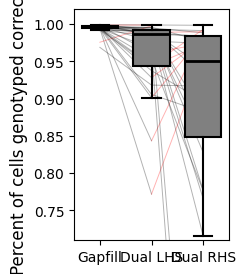

In [5]:
fig, ax = plt.subplots(figsize=(2,3))

data = [
    merged_accuracies_variants['gapfill'],
    merged_accuracies_variants['dual_lhs'],
    merged_accuracies_variants['dual_rhs']
]

alpha = 0.3
for i in range(len(data[0])): ### add lines for individual datapoints
    if data[0][i] >= data[1][i]:
        ax.plot([1,2], [data[0][i], data[1][i]], 'k', alpha=alpha, linewidth=0.7)
    if data[0][i] < data[1][i]:
        ax.plot([1,2], [data[0][i], data[1][i]], color='red', alpha=alpha, linewidth=0.7)

for i in range(len(data[0])): ### add lines for individual datapoints
    if data[1][i] >= data[2][i]:
        ax.plot([2,3], [data[1][i], data[2][i]], 'k', alpha=alpha, linewidth=0.7)
    if data[1][i] < data[2][i]:
        ax.plot([2,3], [data[1][i], data[2][i]], color='red', alpha=alpha, linewidth=0.7)

ax.boxplot(
    data,
    tick_labels=[
        'Gapfill',
        'Dual LHS',
        'Dual RHS'
    ],
    patch_artist=True,
    boxprops=dict(facecolor='grey', color='k', linewidth=1.5),
    medianprops=dict(color='k', linewidth=2),
    whiskerprops=dict(color='k', linewidth=1.5),
    capprops=dict(color='k', linewidth=1.5),
    showfliers=False,
    widths=0.7  # Make boxes wider
)

ax.set_ylim(0.71, 1.02)
ax.set_ylabel('Percent of cells genotyped correctly', fontsize=12)
plt.savefig('../plots/dual_vs_gapfill_accuracy.pdf', bbox_inches='tight')


In [6]:
## check number of variants included
len(merged_accuracies_variants)

30

In [7]:
## statistical test

l1 = merged_accuracies_variants['gapfill']
l2 = merged_accuracies_variants['dual_lhs']

st.wilcoxon(l1, l2, alternative='greater')

WilcoxonResult(statistic=446.0, pvalue=2.859160304069519e-07)

In [8]:
l1 = merged_accuracies_variants['dual_lhs']
l2 = merged_accuracies_variants['dual_rhs']

st.wilcoxon(l1, l2, alternative='greater')

WilcoxonResult(statistic=346.0, pvalue=0.009264740161597729)

In [9]:
## check 10th percentile for gapfill vs dual
merged_accuracies_variants['gapfill'].quantile(0.1), merged_accuracies_variants['dual_lhs'].quantile(0.1)

(0.9922817193635645, 0.9052661972456462)